# CATEGORICAL MODEL (FORWARD AND REVERSED)

---



https://docs.google.com/spreadsheets/d/1GYZ3sUonr3G5iAELIpYgBoKwYyIGBNBg/edit?usp=sharing&ouid=117790341944268011512&rtpof=true&sd=true

In [ ]:
# -*- coding: utf-8 -*-
"""
=============================================================================
FULL ML PIPELINE — FORWARD + REVERSE MODELS WITH CATEGORICAL VARIABLES IN BAL
=============================================================================
One self-contained code block.

KEY CHANGES vs. original:
  • BAL uncertainty estimation uses BOTH numeric AND one-hot encoded categorical
    features (Leaching agent, Type of reducing agent) when fitting the RF oracle.
  • Reverse model OUTPUTS now include the two categorical process conditions
    (label-encoded so they can be predicted by regressors, then decoded).
  • A side-by-side performance table is printed for Original vs BAL on both
    the forward (withcat / nocat) and reverse pipelines.
=============================================================================
"""

# %matplotlib inline
import os, warnings, pickle
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection    import train_test_split, RandomizedSearchCV
from sklearn.preprocessing      import (StandardScaler, OneHotEncoder,
                                        LabelEncoder)
from sklearn.impute             import SimpleImputer
from sklearn.compose            import ColumnTransformer
from sklearn.pipeline           import Pipeline
from sklearn.multioutput        import MultiOutputRegressor
from sklearn.metrics            import (r2_score, mean_squared_error,
                                        mean_absolute_error)
from sklearn.inspection         import permutation_importance
from sklearn.ensemble           import GradientBoostingRegressor, RandomForestRegressor
from sklearn.tree               import DecisionTreeRegressor
from sklearn.svm                import SVR
from sklearn.neural_network     import MLPRegressor
from sklearn.neighbors          import KNeighborsRegressor

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

# ── Reproducibility ─────────────────────────────────────────────────────────
RANDOM_STATE  = 42
np.random.seed(RANDOM_STATE)
N_ITER_SEARCH = 20
CV_FOLDS      = 5
BAL_RATIO     = 0.5      # fraction of original rows selected by BAL
N_CAND_MULT   = 10

os.makedirs("models", exist_ok=True)

# =============================================================================
# 1) LOAD & CLEAN DATA
# =============================================================================
from google.colab import files
uploaded  = files.upload()
file_path = list(uploaded.keys())[0]
df_raw    = pd.read_excel(file_path, header=None)

df         = df_raw.drop(index=0).reset_index(drop=True)
raw_header = df.iloc[0].astype(str)
clean_header = (
    raw_header.str.replace(r"^\s*0\s*", "", regex=True)
              .str.replace("\n", " ").str.replace("\r", " ")
              .str.strip().str.replace("  ", " ")
)
df.columns = clean_header
df = df.drop(index=0).reset_index(drop=True)
df.head()

Saving ReducingAgentData (1).xlsx to ReducingAgentData (1) (2).xlsx


,Li in feed %,Co in feed %,Mn in feed %,Ni in feed %,Leaching agent,"Concentration, M",Type of reducing agent,Concentration %,"Time,min","Temperature, C",Li,Co,Mn,Ni
0,NaN,NaN,NaN,NaN,ORGANIC_ACID,NaN,YES,NaN,NaN,NaN,98,99,NaN,NaN
1,NaN,NaN,NaN,NaN,ORGANIC_ACID,NaN,YES,NaN,NaN,NaN,98,95,NaN,NaN
2,6.79,17.68,16.46,17.58,ORGANIC_ACID,0.5,YES,0.5,30,60,70.62,70.19,71.25,71.42
3,6.79,17.68,16.46,17.58,ORGANIC_ACID,1,YES,1,40,60,82.37,70.77,78.64,72.45
4,6.79,17.68,16.46,17.58,ORGANIC_ACID,1.5,YES,1.5,50,60,87.77,76.06,80.21,75.97



Dataset loaded: 1012 rows × 14 columns


,count,mean,std,min,25%,50%,75%,max,median,missing
0,,,,,,,,,,
Li in feed %,1012.000000,4.823626,1.768883,1.650000,3.470000,5.150000,6.500000,7.420000,5.150000,0
Co in feed %,1012.000000,28.281759,16.672974,0.100000,16.000000,23.670000,43.350000,60.200000,23.670000,0
Mn in feed %,1012.000000,6.223668,5.220157,0.140000,4.040000,4.040000,4.040000,19.530000,4.040000,0
Ni in feed %,1012.000000,10.364735,9.396004,0.020000,1.210000,10.060000,11.850000,36.000000,10.060000,0
"Concentration, M",1012.000000,1.828332,1.255562,0.100000,1.000000,1.500000,2.000000,6.000000,1.500000,0
Concentration %,1012.000000,1.983258,2.822723,0.000000,1.000000,1.000000,2.000000,25.000000,1.000000,0
"Time,min",1012.000000,80.074111,121.610604,0.000000,30.000000,60.000000,100.000000,1080.000000,60.000000,0
"Temperature, C",1012.000000,65.472332,18.423854,20.000000,50.000000,70.000000,80.000000,100.000000,70.000000,0
Li,1012.000000,83.645709,21.756723,0.000000,78.000000,92.000000,98.000000,102.000000,92.000000,0


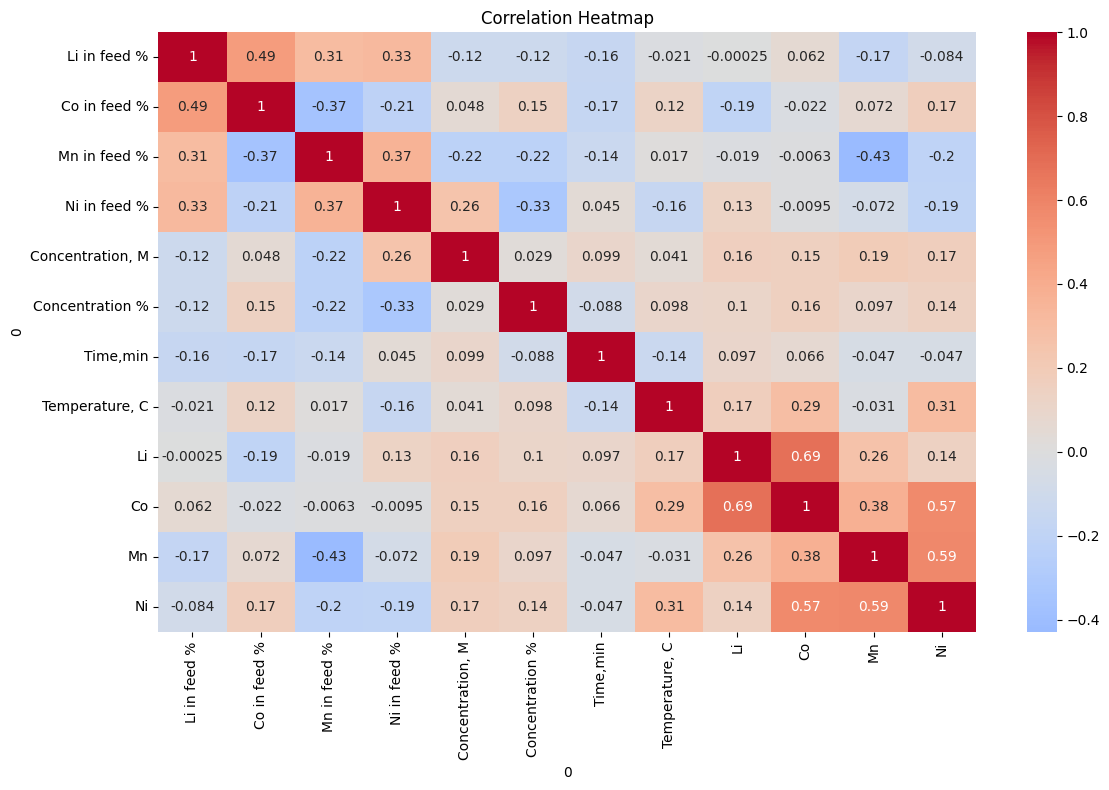


FORWARD PIPELINE: withcat

  ── TARGET: Li ──


,Model,Train R²,Train RMSE,Train MAE,Test R²,Test RMSE,Test MAE
3,RandomForest,0.964198,17.191565,2.285329,0.837867,71.350493,4.795916
0,GBR,0.838571,77.514429,6.205216,0.757621,106.664681,7.178041
2,ANN,0.681727,152.827869,8.709892,0.653047,152.684711,8.502105
5,KNN,0.770758,110.077118,5.767569,0.651998,153.146127,6.764936
4,DecisionTree,0.989379,5.099794,0.460587,0.636773,159.846499,5.304341
1,SVM,0.114625,425.137694,11.411585,0.141686,377.720871,10.411497


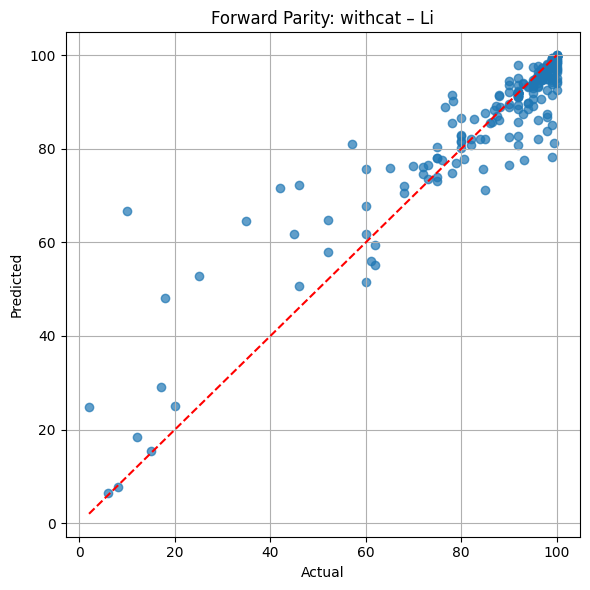

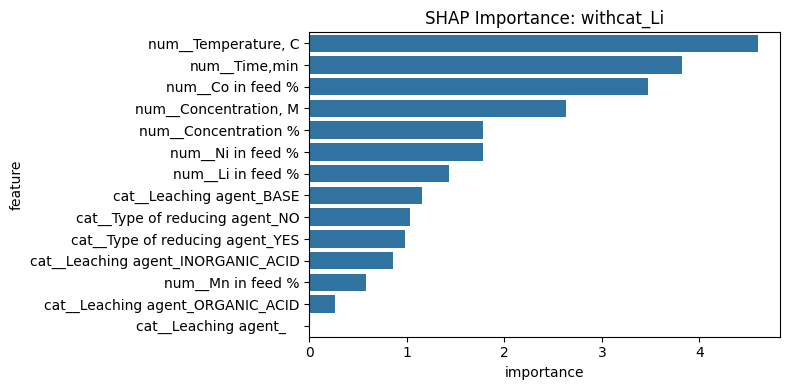

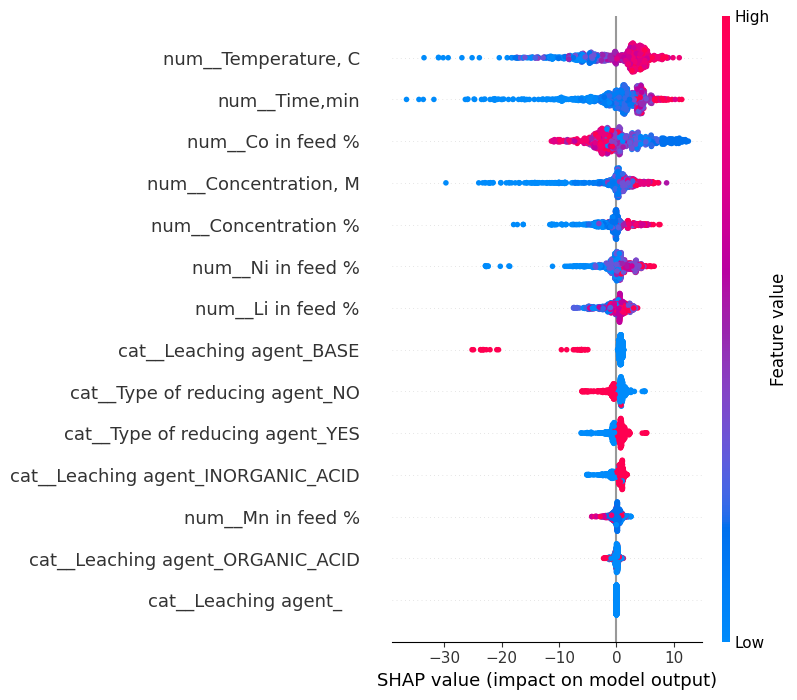


  ── TARGET: Co ──


,Model,Train R²,Train RMSE,Train MAE,Test R²,Test RMSE,Test MAE
3,RandomForest,0.929891,47.930959,3.920092,0.811348,123.434899,7.152578
4,DecisionTree,0.954747,30.937996,1.612618,0.719073,183.810367,7.594848
0,GBR,0.777116,152.377102,9.427656,0.679866,209.463077,11.224376
5,KNN,0.734264,181.672999,8.430759,0.639797,235.680137,9.822069
2,ANN,0.618617,260.736342,12.293198,0.565720,284.148741,12.822574
1,SVM,0.211080,539.353014,17.452918,0.233574,501.471246,16.513700


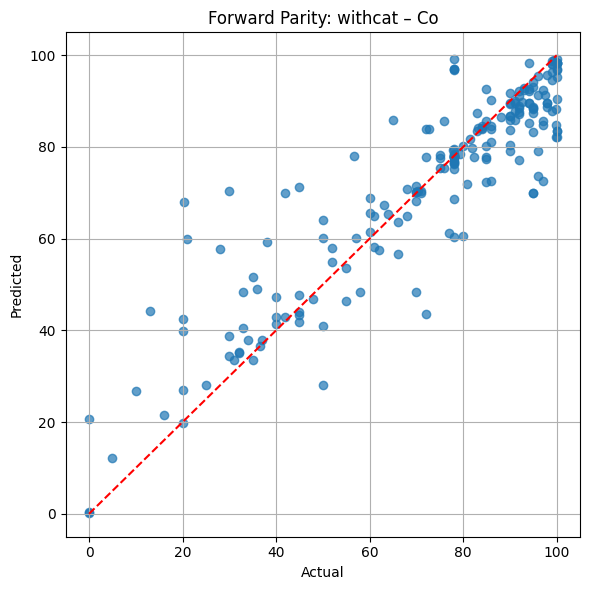

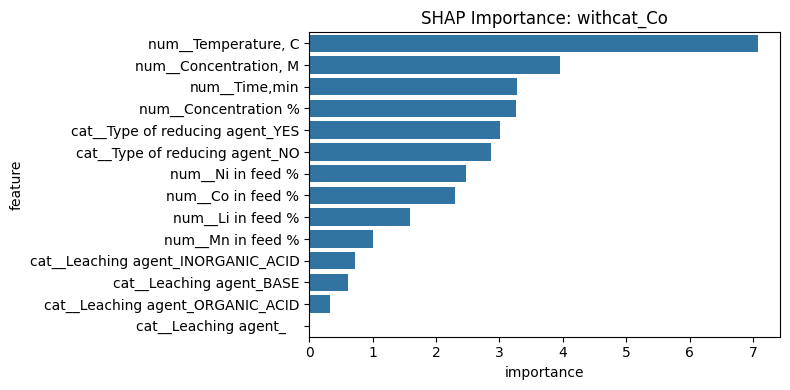

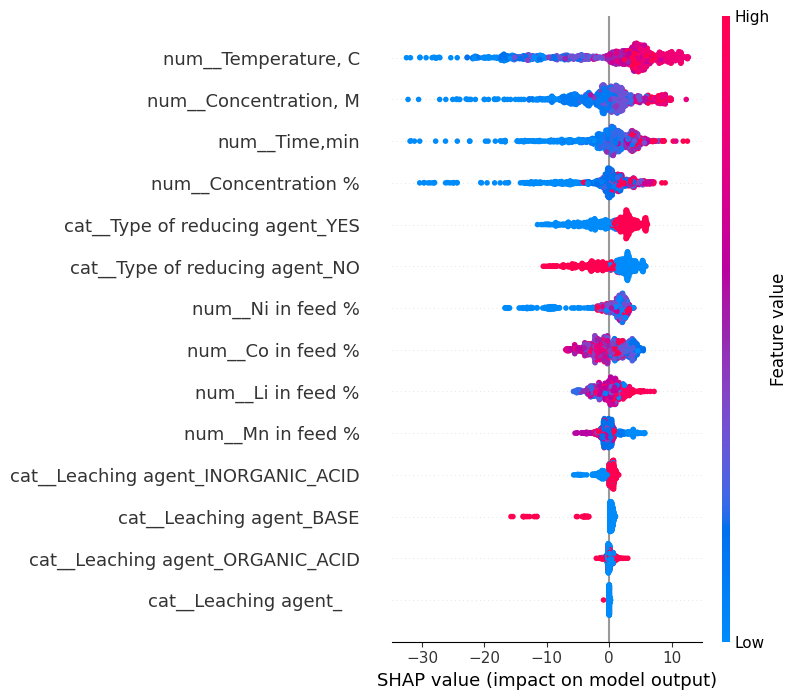


  ── TARGET: Mn ──


,Model,Train R²,Train RMSE,Train MAE,Test R²,Test RMSE,Test MAE
3,RandomForest,0.936853,18.807679,1.375950,0.829083,53.384809,2.690366
4,DecisionTree,0.961170,11.564996,0.482218,0.770605,71.649897,2.939127
0,GBR,0.849702,44.764560,3.166751,0.768554,72.290745,4.055248
5,KNN,0.748247,74.981850,3.139174,0.718479,87.931048,3.604414
2,ANN,0.584115,123.866531,6.516884,0.582090,130.531429,6.926968
1,SVM,0.100392,267.938098,6.650528,0.108982,278.303472,7.142289


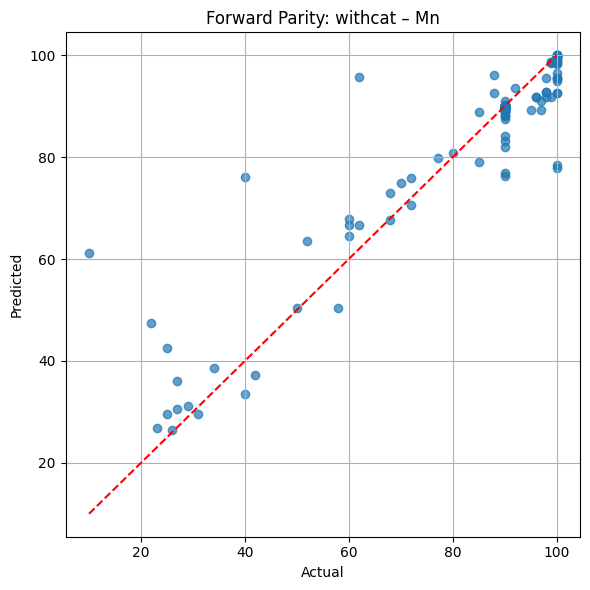

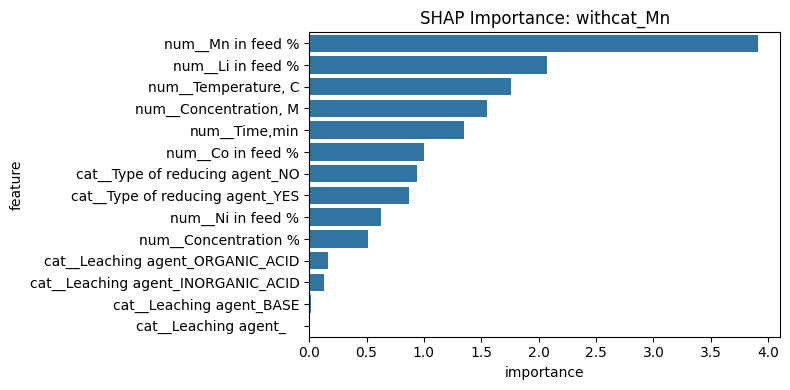

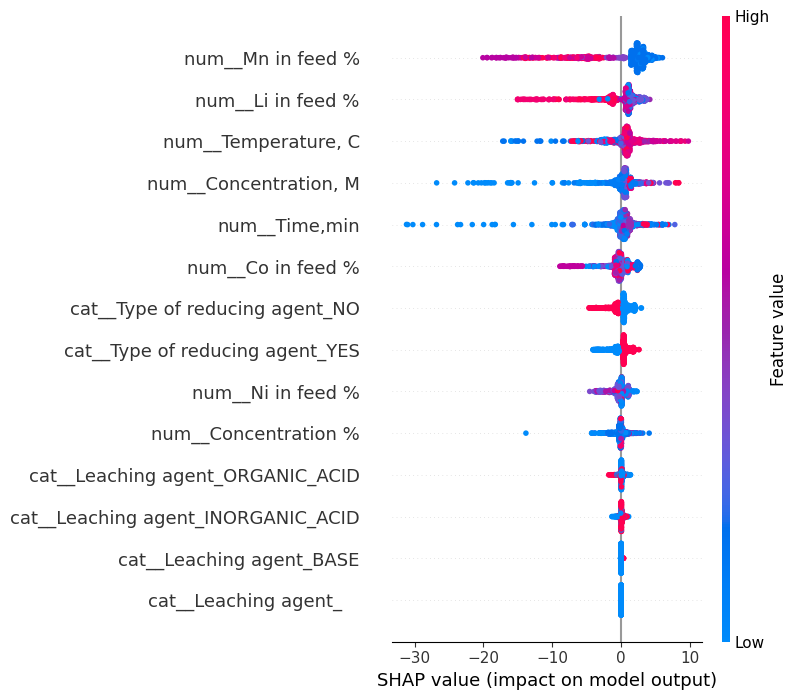


  ── TARGET: Ni ──


,Model,Train R²,Train RMSE,Train MAE,Test R²,Test RMSE,Test MAE
3,RandomForest,0.928422,21.110191,1.785775,0.826978,43.210811,2.974138
0,GBR,0.829486,50.288759,3.907617,0.743914,63.955307,4.604699
4,DecisionTree,0.951522,14.297366,0.815810,0.720443,69.817050,3.452400
5,KNN,0.717354,83.359541,3.757953,0.663060,84.147861,4.112463
2,ANN,0.472141,155.678959,7.235945,0.354462,161.217545,7.583206
1,SVM,0.028996,286.373574,7.257696,0.009742,247.308595,6.627239


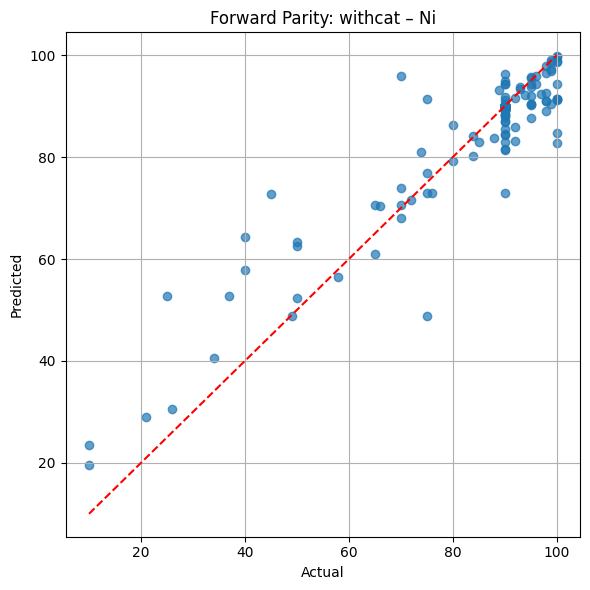

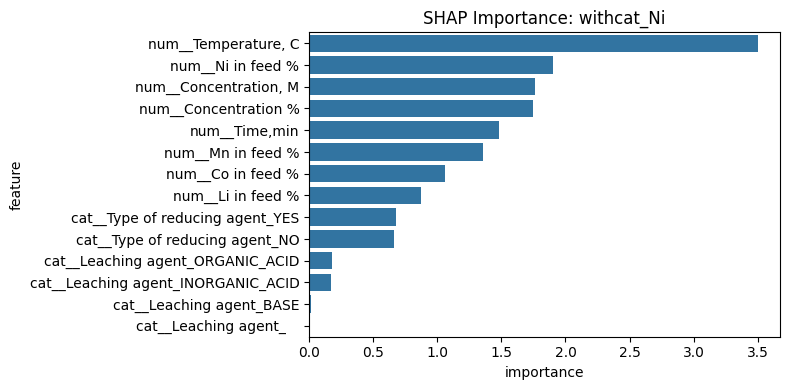

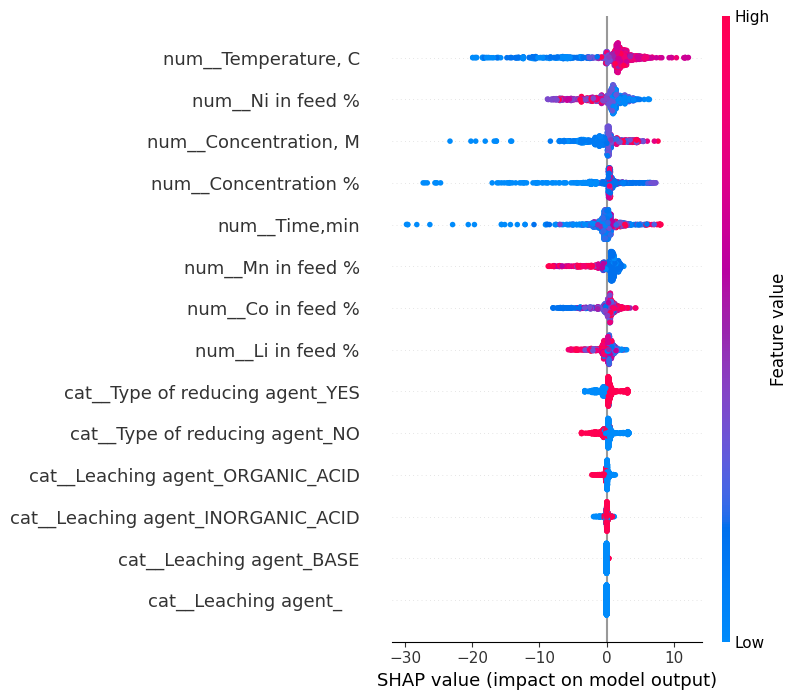


FORWARD PIPELINE: nocat

  ── TARGET: Li ──


,Model,Train R²,Train RMSE,Train MAE,Test R²,Test RMSE,Test MAE
3,RandomForest,0.956755,20.765479,2.467279,0.724613,121.190538,5.537799
4,DecisionTree,0.989071,5.247713,0.498494,0.644194,156.580767,5.567870
5,KNN,0.740876,124.425641,6.199341,0.630525,162.595874,7.357094
0,GBR,0.793081,99.358131,6.709172,0.627865,163.766602,8.250478
2,ANN,0.589656,197.037995,9.694710,0.562834,192.385147,9.411463
1,SVM,0.098281,432.985400,11.511801,0.130969,382.437250,10.565437


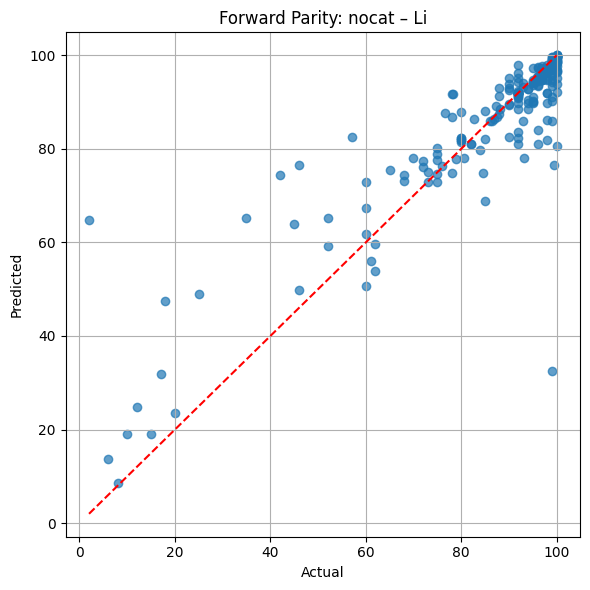

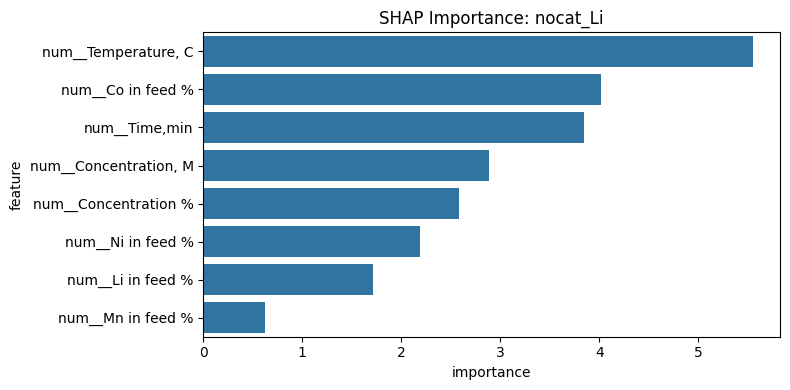

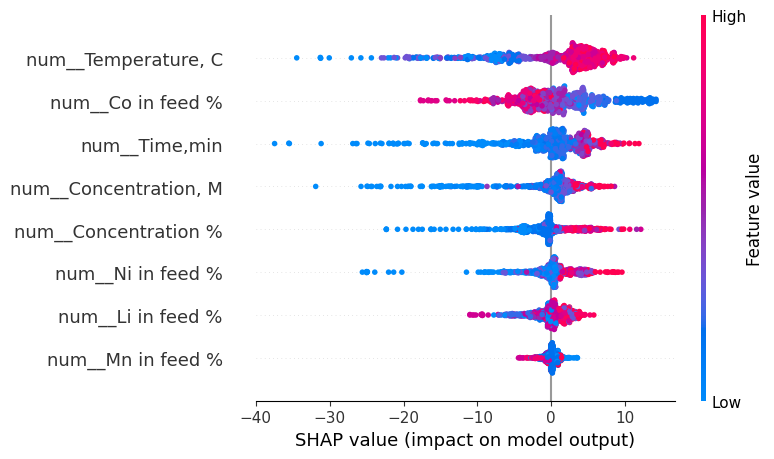


  ── TARGET: Co ──


,Model,Train R²,Train RMSE,Train MAE,Test R²,Test RMSE,Test MAE
3,RandomForest,0.927028,49.887863,4.070612,0.742326,168.595973,7.884685
4,DecisionTree,0.954015,31.438202,1.682663,0.625793,244.842904,8.465800
0,GBR,0.764140,161.248019,9.529851,0.604172,258.989427,11.766467
5,KNN,0.696324,207.610968,9.481958,0.598456,262.729689,10.866424
2,ANN,0.553864,305.005170,13.974261,0.498393,328.200588,14.523657
1,SVM,0.123999,598.886660,18.493133,0.172842,541.208575,17.218764


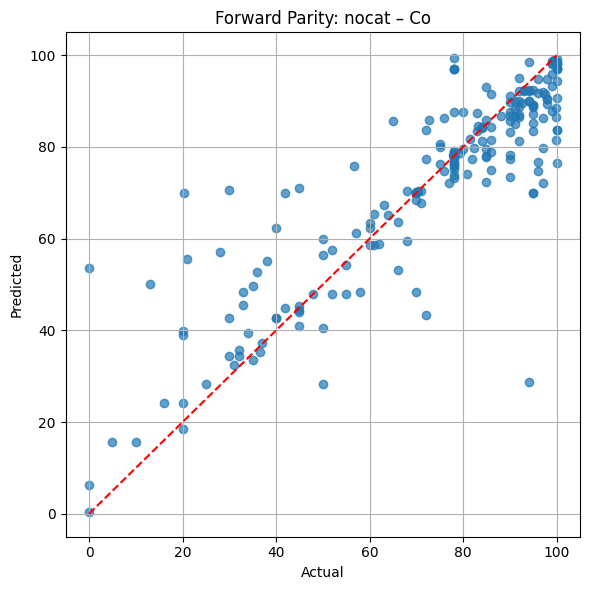

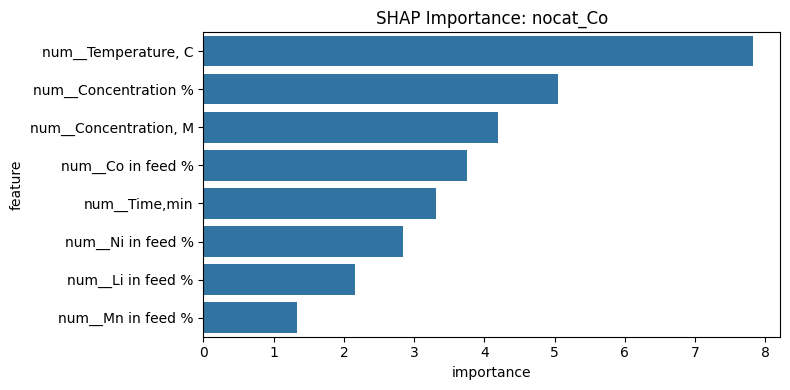

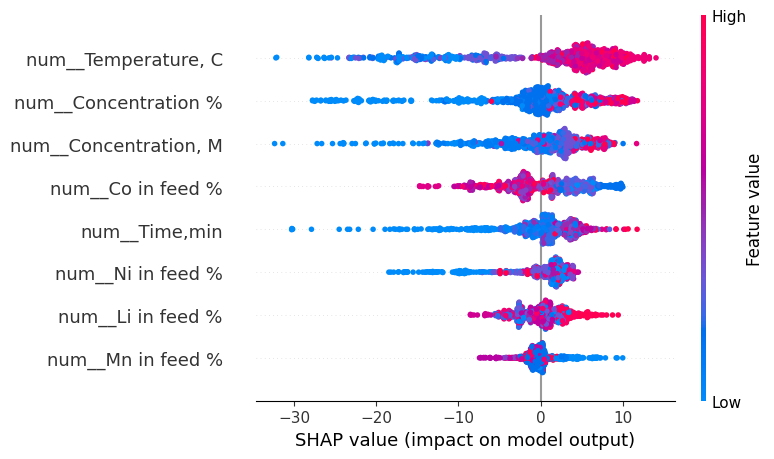


  ── TARGET: Mn ──


,Model,Train R²,Train RMSE,Train MAE,Test R²,Test RMSE,Test MAE
3,RandomForest,0.933302,19.865353,1.490214,0.813805,58.156682,2.973097
4,DecisionTree,0.957354,12.701585,0.599647,0.756644,76.010550,3.144152
0,GBR,0.845584,45.991162,3.238357,0.740840,80.946860,4.374416
5,KNN,0.729595,80.537033,3.488210,0.636634,113.494989,4.535448
2,ANN,0.589038,122.400464,6.338145,0.571692,133.779048,6.819102
1,SVM,0.084122,272.783859,6.836614,0.082152,286.683576,7.389975


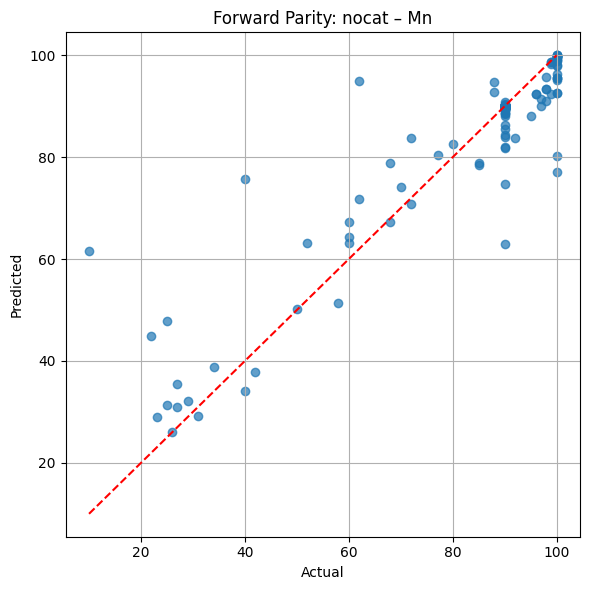

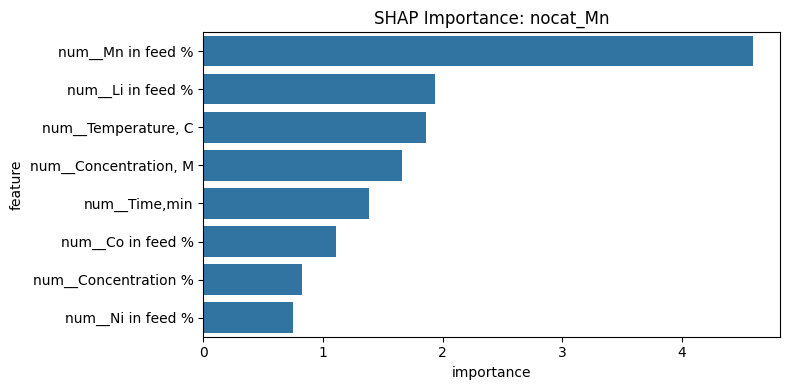

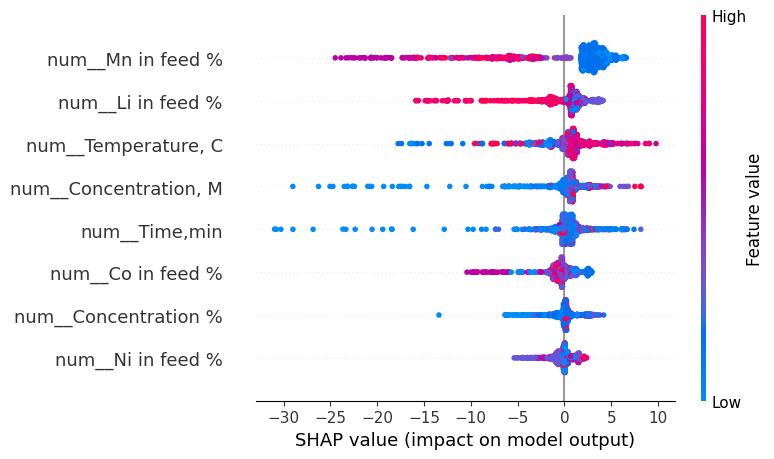


  ── TARGET: Ni ──


,Model,Train R²,Train RMSE,Train MAE,Test R²,Test RMSE,Test MAE
3,RandomForest,0.927854,21.277732,1.838367,0.818732,45.270261,3.003523
0,GBR,0.824335,51.808042,3.913857,0.731992,66.932777,4.622068
4,DecisionTree,0.951294,14.364733,0.844240,0.716762,70.736217,3.366341
5,KNN,0.693203,90.482282,4.229528,0.639856,89.942956,4.509212
2,ANN,0.455160,160.686944,8.002438,0.388615,152.688179,8.029448
1,SVM,0.000933,294.650105,7.407051,0.001562,249.351366,6.694553


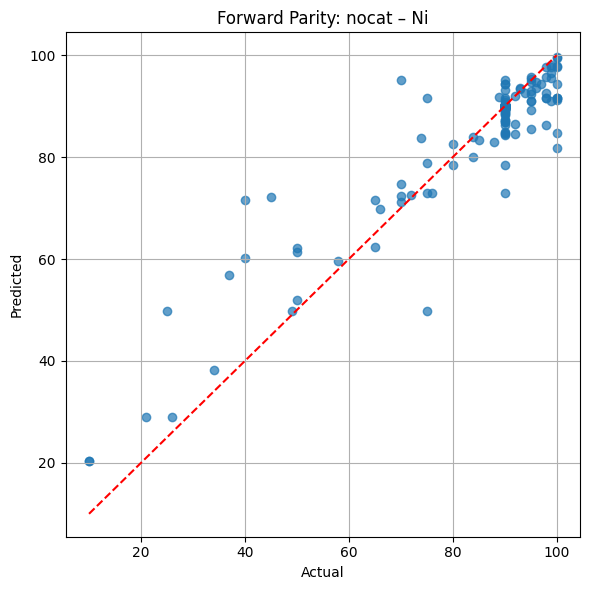

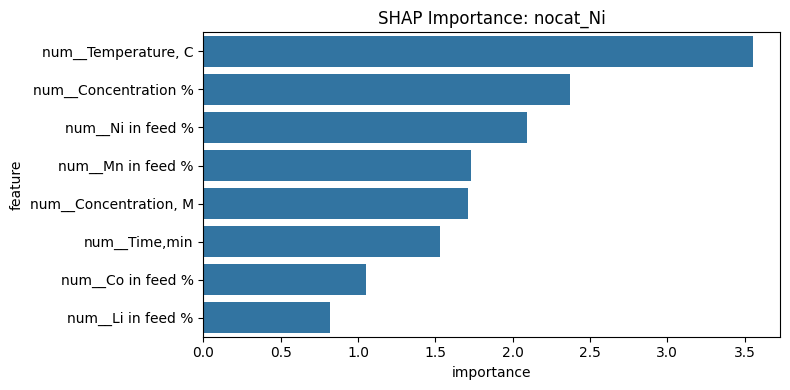

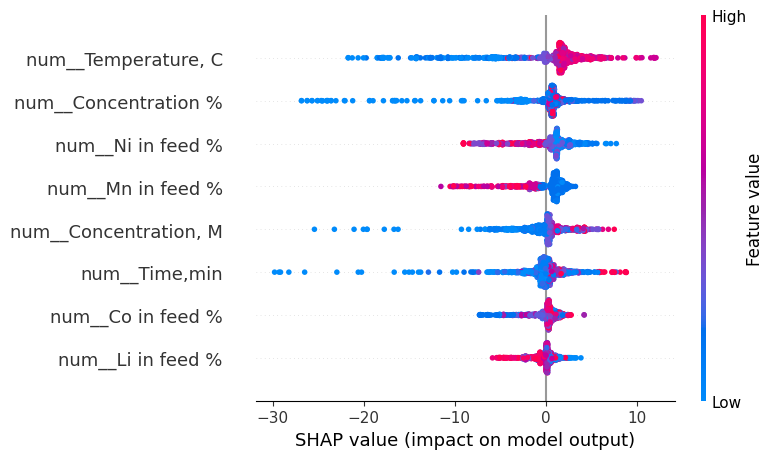


BAYESIAN ACTIVE LEARNING  (categorical included in uncertainty)
  Selected 506 BAL rows for target 'Li'
  Selected 506 BAL rows for target 'Co'
  Selected 506 BAL rows for target 'Mn'
  Selected 506 BAL rows for target 'Ni'

FORWARD: ORIGINAL vs BAL COMPARISON

  === withcat | Li ===


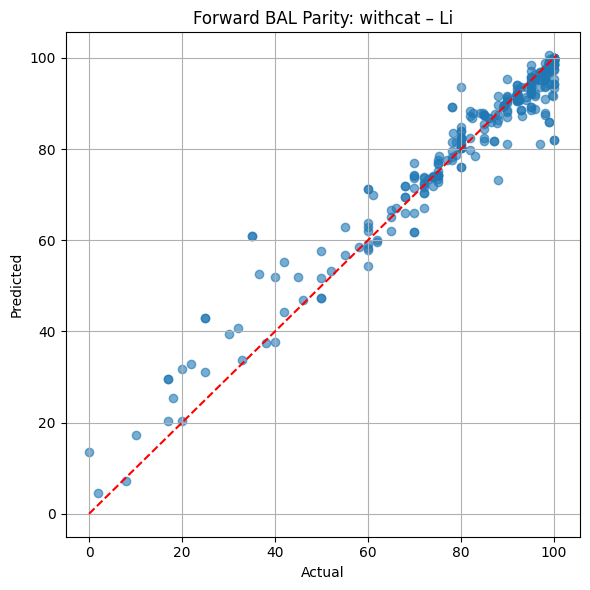


  === withcat | Co ===


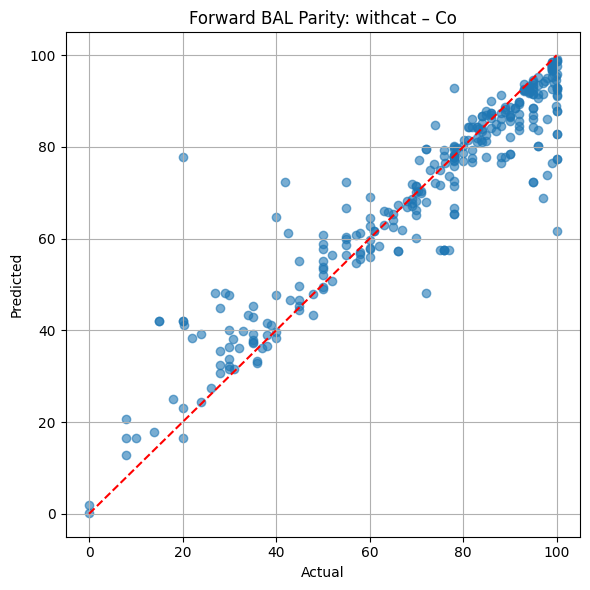


  === withcat | Mn ===


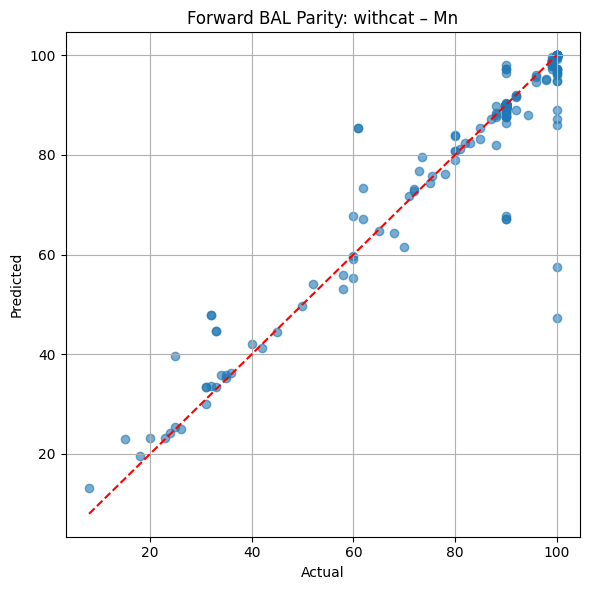


  === withcat | Ni ===


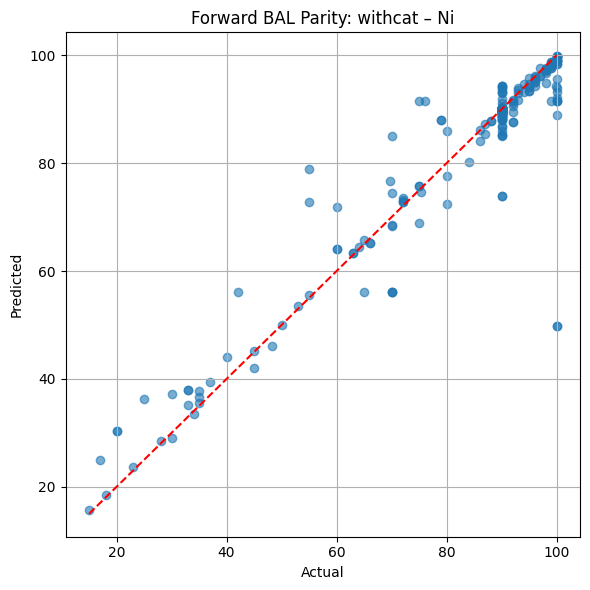


  === nocat | Li ===


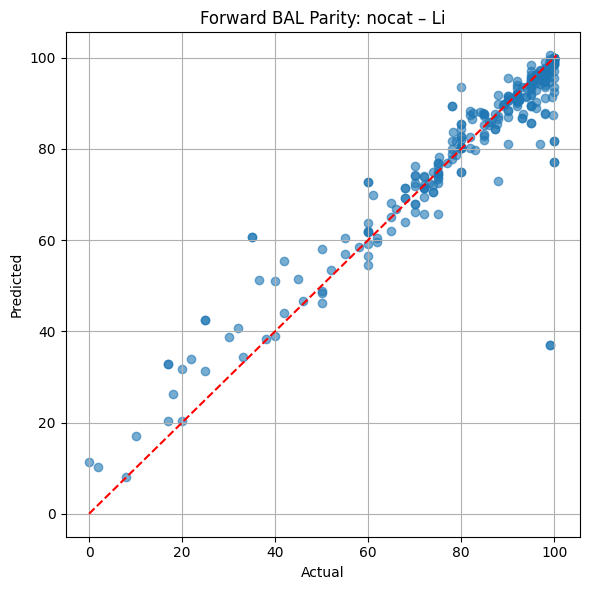


  === nocat | Co ===


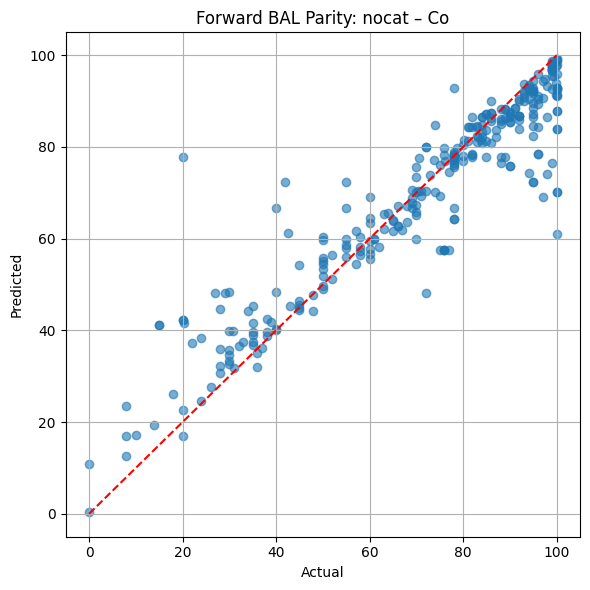


  === nocat | Mn ===


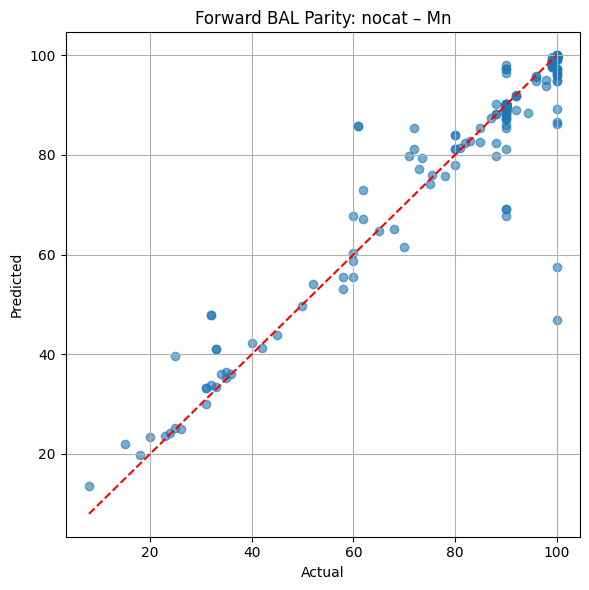


  === nocat | Ni ===


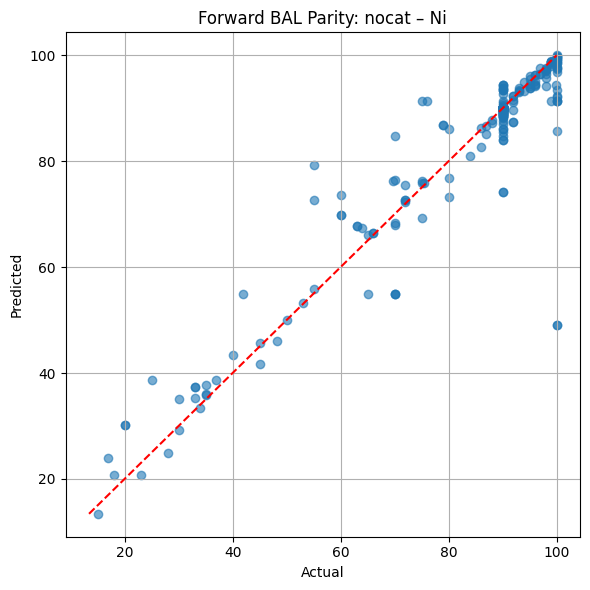

,pipeline,target,dataset,R2,RMSE,MAE
0,withcat,Li,Original,0.843,69.1701,4.4977
1,withcat,Li,BAL,0.942,26.8210,3.1165
2,withcat,Co,Original,0.810,124.5727,7.2592
3,withcat,Co,BAL,0.870,84.1086,5.7443
4,withcat,Mn,Original,0.861,43.3625,2.4775
5,withcat,Mn,BAL,0.906,32.4869,1.8658
6,withcat,Ni,Original,0.853,36.6837,2.8742
7,withcat,Ni,BAL,0.895,33.3320,2.2290
8,nocat,Li,Original,0.779,97.3715,5.0482
9,nocat,Li,BAL,0.878,55.9371,3.6899



REVERSE MODEL — INCLUDES CATEGORICAL OUTPUTS

  ── Reverse: Original ──
    ✓ GBR
    ✓ RandomForest
    ✓ DecisionTree
    ✓ SVM
    ✓ ANN
    ✓ KNN
  🏆 Best (Original): RandomForest

  ── Reverse: BAL ──
    ✓ GBR
    ✓ RandomForest
    ✓ DecisionTree
    ✓ SVM
    ✓ ANN
    ✓ KNN
  🏆 Best (BAL): GBR


,Model,R2,RMSE,MAE
1,RandomForest,0.471,394.0847,6.2300
2,DecisionTree,0.295,450.4332,5.9189
3,SVM,0.096,483.8108,7.8775
0,GBR,0.378,521.8129,7.3945
4,ANN,0.182,634.4343,9.0895
5,KNN,0.337,675.6980,6.7557


,Model,R2,RMSE,MAE
0,GBR,0.468,466.2096,7.5395
1,RandomForest,0.452,546.3072,6.8250
5,KNN,0.434,631.3955,6.9796
4,ANN,0.353,1075.6165,8.9314
2,DecisionTree,0.191,1416.1832,7.7427
3,SVM,0.123,1606.4375,9.0894


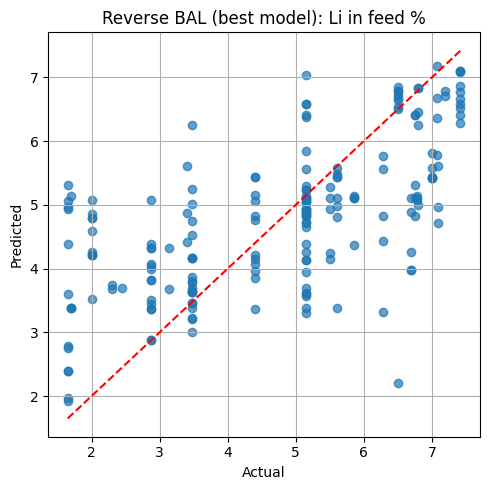

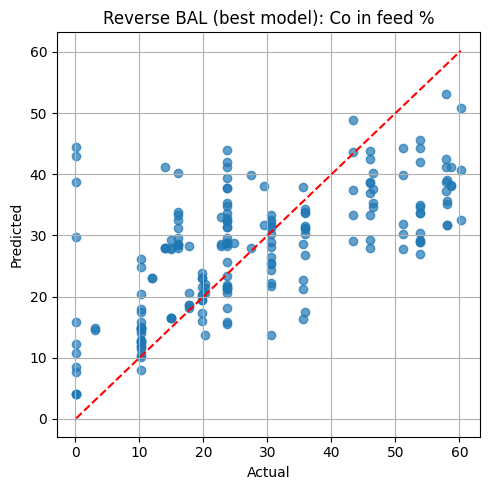

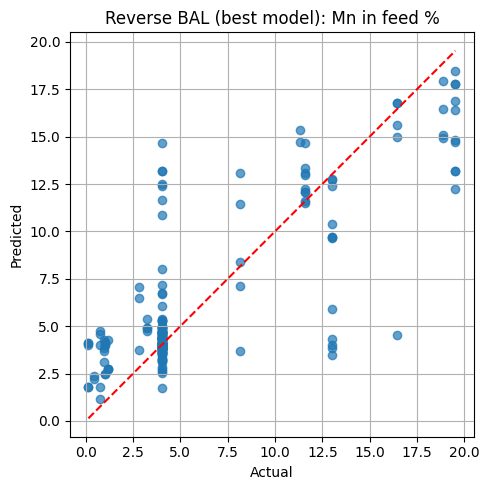

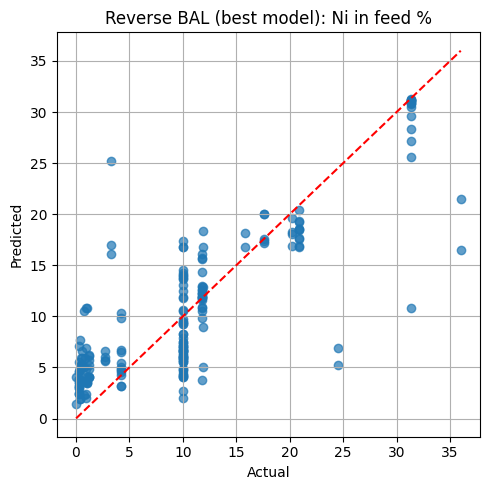

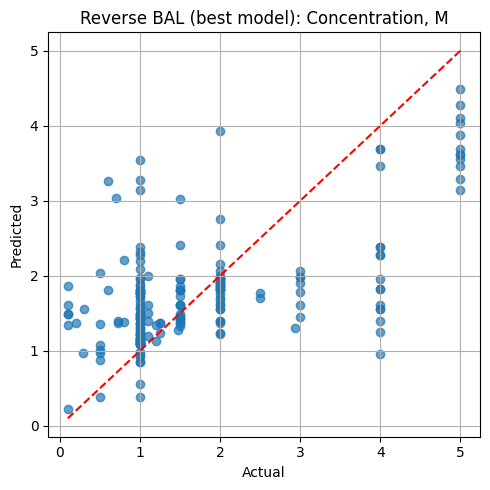

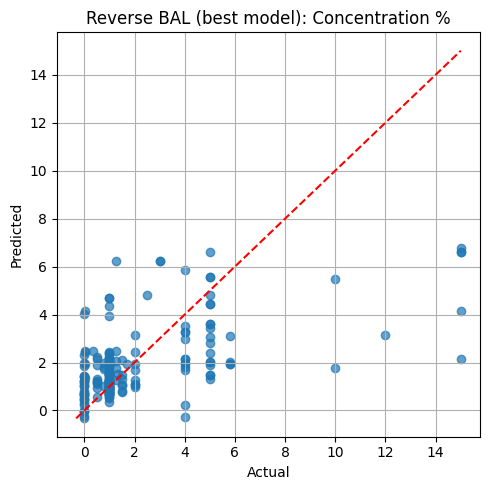

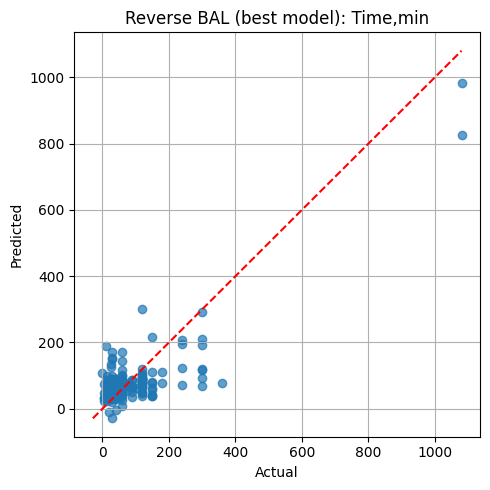

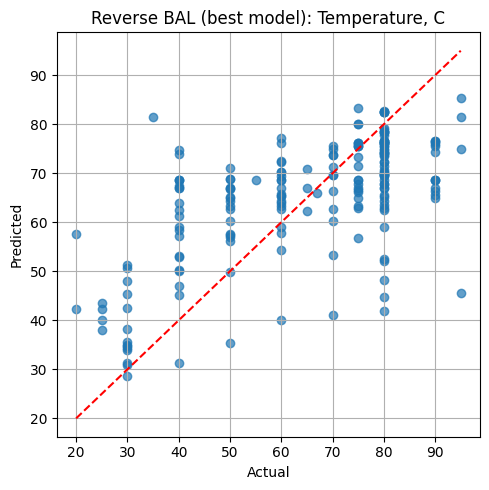

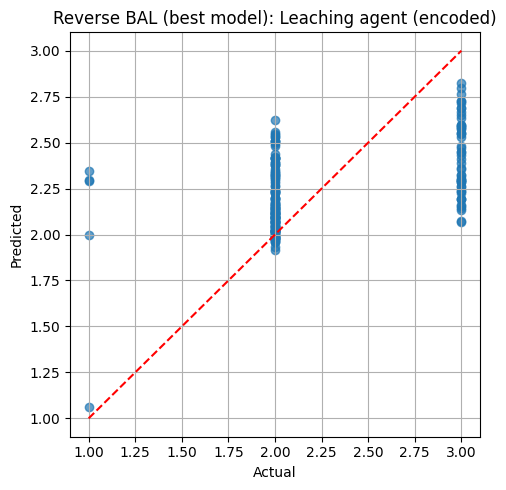

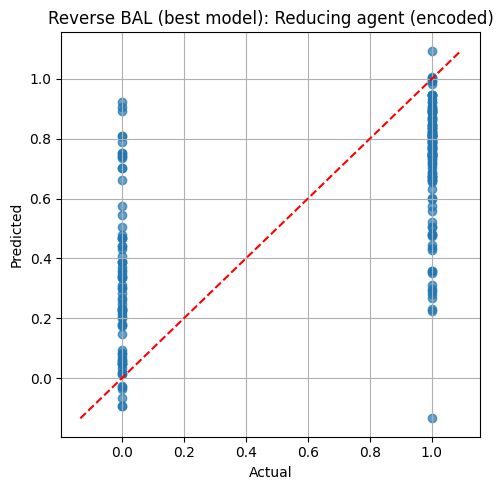

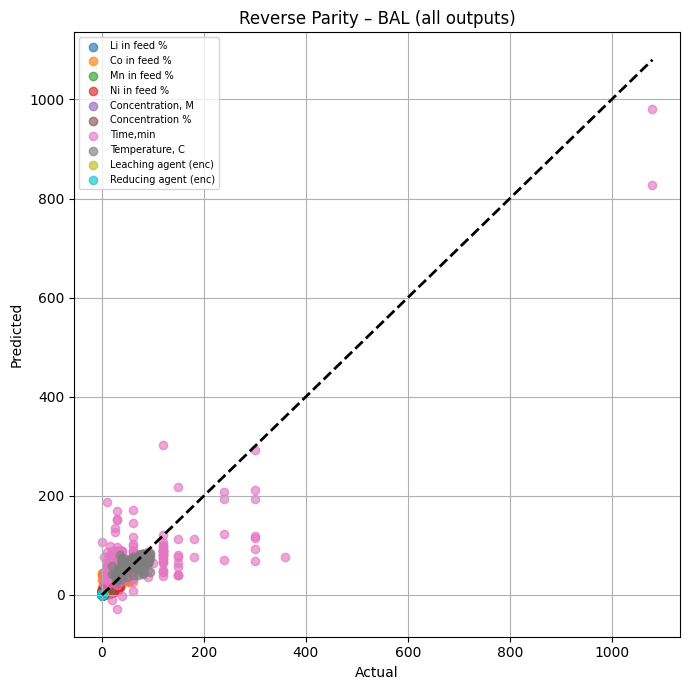


DECODED REVERSE PREDICTIONS (BAL best model — test split)


,Li in feed %,Co in feed %,Mn in feed %,Ni in feed %,"Concentration, M",Concentration %,"Time,min","Temperature, C",True Leaching agent,Predicted Leaching agent,True Reducing agent,Predicted Reducing agent
0,5.150000,30.500000,4.040000,31.300000,5.000000,1.000000,120.000000,60.000000,INORGANIC_ACID,INORGANIC_ACID,NO,NO
1,5.150000,23.670000,4.040000,10.060000,0.100000,0.020000,120.000000,80.000000,ORGANIC_ACID,INORGANIC_ACID,YES,YES
2,3.470000,10.160000,4.040000,11.820000,1.000000,0.000000,60.000000,30.000000,INORGANIC_ACID,INORGANIC_ACID,NO,NO
3,5.600000,46.060000,4.040000,1.210000,2.000000,1.250000,90.000000,60.000000,ORGANIC_ACID,INORGANIC_ACID,YES,YES
4,1.700000,14.000000,1.192000,0.482000,2.000000,5.000000,45.000000,80.000000,INORGANIC_ACID,INORGANIC_ACID,YES,YES
5,2.000000,16.000000,4.040000,10.060000,4.000000,1.000000,150.000000,80.000000,INORGANIC_ACID,INORGANIC_ACID,NO,NO
6,6.760000,57.940000,0.760000,0.910000,1.500000,4.000000,10.000000,50.000000,ORGANIC_ACID,INORGANIC_ACID,YES,YES
7,6.760000,57.940000,0.760000,0.910000,1.500000,4.000000,10.000000,90.000000,ORGANIC_ACID,INORGANIC_ACID,YES,YES
8,7.080000,20.260000,18.890000,20.190000,1.200000,1.500000,30.000000,50.000000,ORGANIC_ACID,ORGANIC_ACID,YES,YES
9,3.470000,10.160000,4.040000,11.820000,1.000000,0.000000,40.000000,30.000000,INORGANIC_ACID,INORGANIC_ACID,YES,YES



  Leaching agent prediction accuracy : 76.41%
  Reducing agent prediction accuracy  : 82.05%


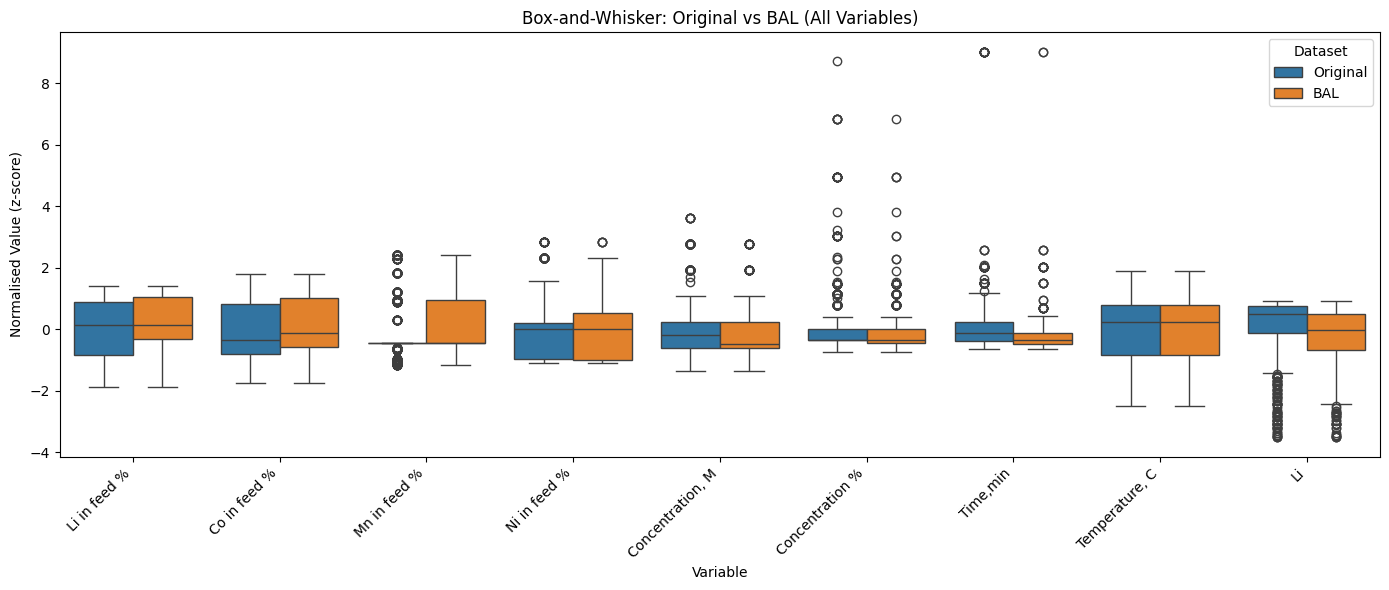

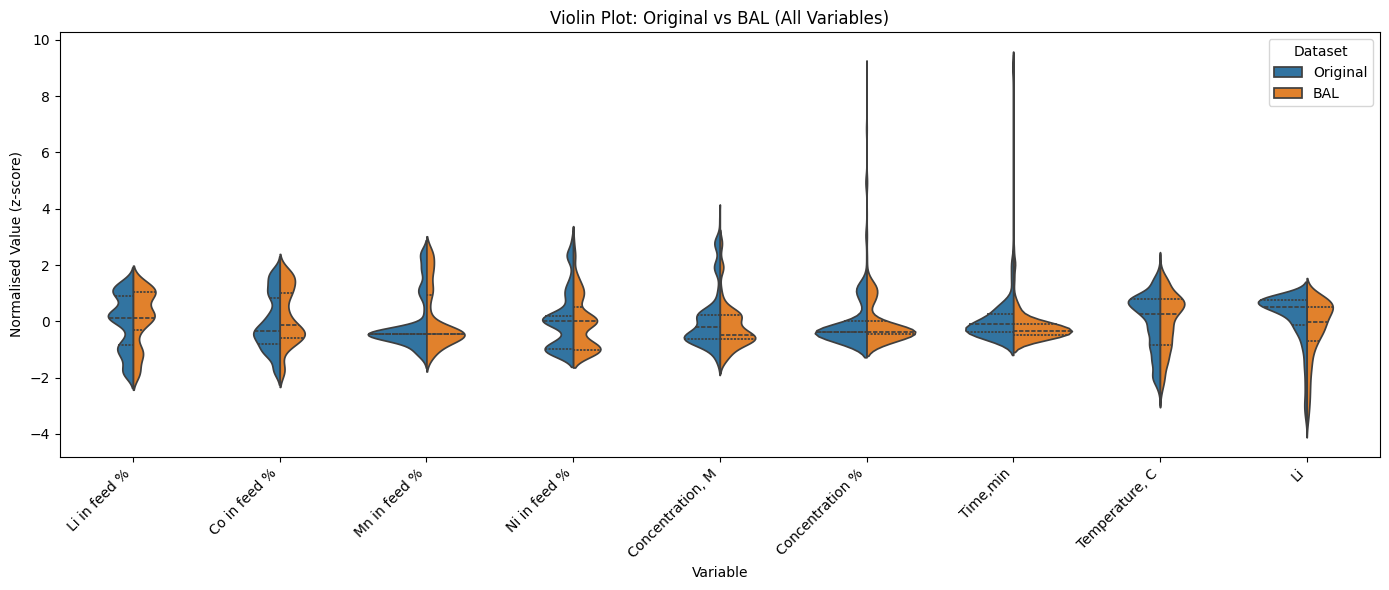


Generating Partial Dependence Plots...
Calculating permutation importance for feature selection...
Top features used for PDP:
['Concentration %', 'Temperature, C', 'Concentration, M', 'Time,min', 'Ni in feed %', 'Mn in feed %']


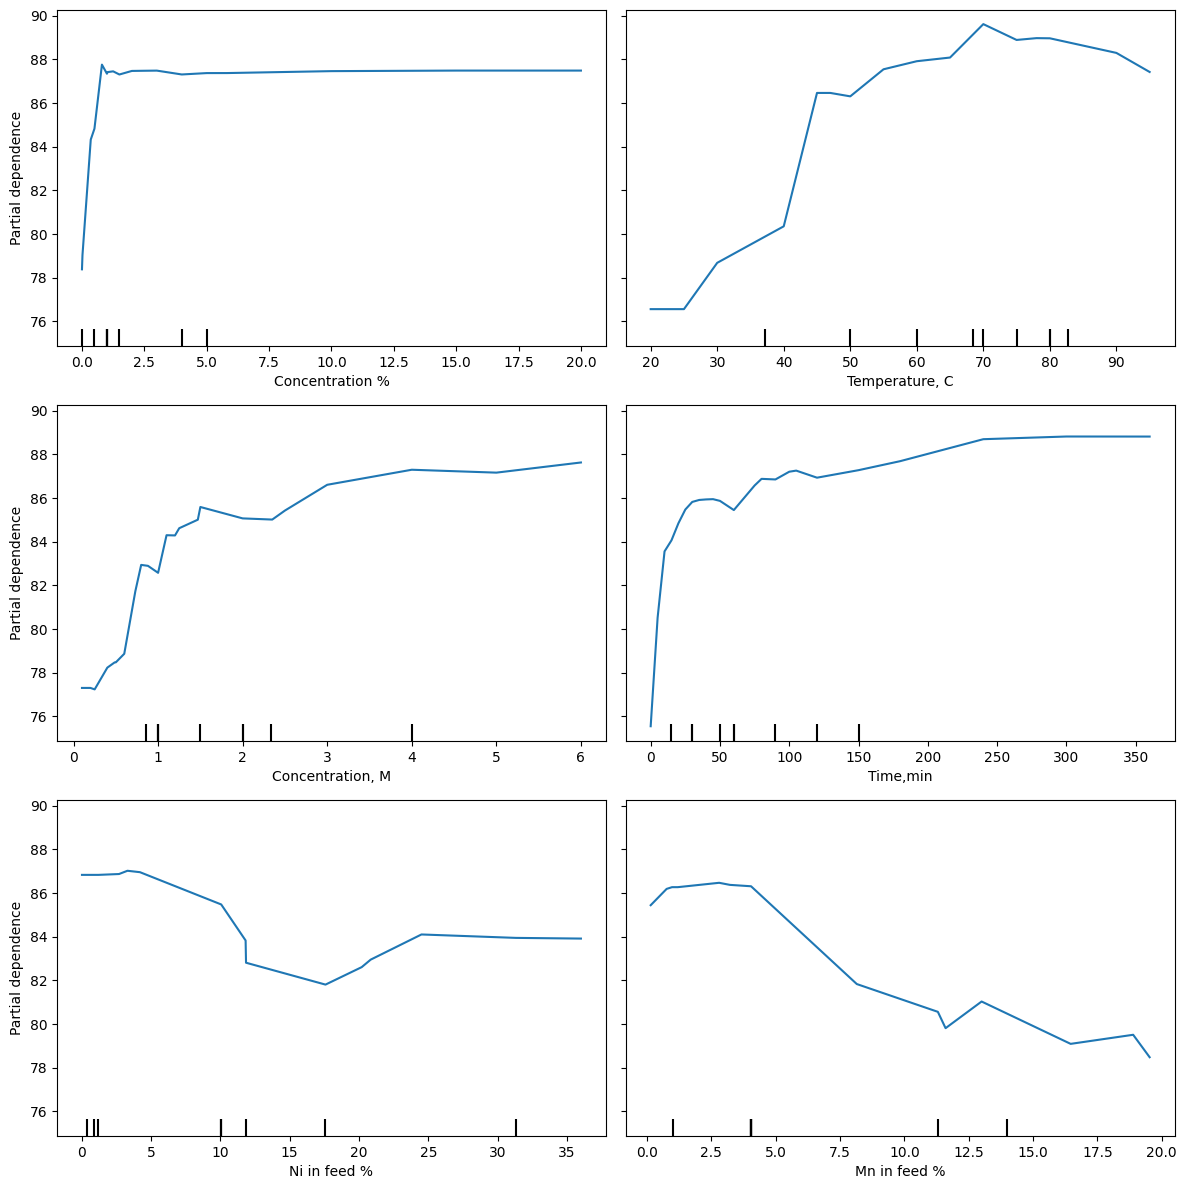


✅ Pipeline complete!
   Saved: predictions_full_dataset.xlsx
          forward_original_vs_BAL_metrics.csv
          reverse_decoded_predictions.csv
          BAL_combined_datasets.xlsx
          models/best_tuned_*.pkl


In [ ]:
# =============================================================================
# 2) COLUMN DEFINITIONS
# =============================================================================
categorical_cols = ["Leaching agent", "Type of reducing agent"]
numeric_cols     = ["Li in feed %", "Co in feed %", "Mn in feed %", "Ni in feed %",
                    "Concentration, M", "Concentration %", "Time,min", "Temperature, C"]
target_cols      = ["Li", "Co", "Mn", "Ni"]

# Check columns
for c in categorical_cols + numeric_cols + target_cols:
    if c not in df.columns:
        print(f"  ⚠ Column not found: '{c}'")

# Cast & impute numerics
for c in numeric_cols + target_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        df[c] = df[c].fillna(df[c].median())

# Fill categorical NaN with mode
for c in categorical_cols:
    if c in df.columns:
        df[c] = df[c].fillna(df[c].mode()[0])

print(f"\nDataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

# =============================================================================
# 3) EDA — summary stats & correlation heatmap
# =============================================================================
present_numeric = [c for c in numeric_cols + target_cols if c in df.columns]
if present_numeric:
    summary          = df[present_numeric].describe().T
    summary["missing"] = df[present_numeric].isna().sum()
    summary["median"]  = df[present_numeric].median()
    display(summary[["count","mean","std","min","25%","50%","75%","max",
                      "median","missing"]].style.background_gradient(cmap="Blues"))

    plt.figure(figsize=(12, 8))
    sns.heatmap(df[present_numeric].corr(), cmap="coolwarm", center=0, annot=True)
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()

# =============================================================================
# 4) FORWARD MODEL — PREPROCESSING PIPELINES
# =============================================================================
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_withcat = ColumnTransformer([
    ("num", numeric_pipeline,     numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
], remainder="drop")

preprocessor_nocat = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols)
], remainder="drop")

# =============================================================================
# 5) CANDIDATE MODELS & HYPERPARAMETER SEARCH SPACES
# =============================================================================
candidates = {
    "GBR":          GradientBoostingRegressor(random_state=RANDOM_STATE),
    "SVM":          SVR(),
    "ANN":          MLPRegressor(random_state=RANDOM_STATE, max_iter=2000),
    "RandomForest": RandomForestRegressor(random_state=RANDOM_STATE),
    "DecisionTree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "KNN":          KNeighborsRegressor()
}

param_distributions = {
    "GBR": {
        "model__n_estimators":  [100, 200, 400],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth":     [2, 3, 4, 5]
    },
    "SVM": {
        "model__C":       [0.1, 1, 10, 100],
        "model__epsilon": [0.01, 0.1, 0.2],
        "model__kernel":  ["linear", "rbf", "poly"]
    },
    "ANN": {
        "model__hidden_layer_sizes": [(50,), (100,), (50, 50)],
        "model__activation":         ["relu", "tanh"],
        "model__alpha":              [0.0001, 0.001, 0.01]
    },
    "RandomForest": {
        "model__n_estimators":    [100, 200, 400],
        "model__max_depth":       [3, 5, 10, None],
        "model__min_samples_split": [2, 5, 10],
        "model__max_features":    ["sqrt", "log2"]
    },
    "DecisionTree": {
        "model__max_depth":         [None, 3, 5, 10],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf":  [1, 2, 4]
    },
    "KNN": {
        "model__n_neighbors": [3, 5, 7, 10],
        "model__weights":     ["uniform", "distance"],
        "model__p":           [1, 2]
    }
}

# =============================================================================
# 6) SHAP / PERMUTATION IMPORTANCE HELPER
# =============================================================================
def compute_and_show_importance(model, preprocessor, X, y, top_n=20, model_name="model"):
    try:
        X_proc = preprocessor.transform(X)
    except Exception:
        preprocessor.fit(X)
        X_proc = preprocessor.transform(X)

    try:
        feature_names = list(preprocessor.get_feature_names_out())
    except Exception:
        feature_names = list(numeric_cols)
        cat_t = preprocessor.named_transformers_.get("cat", None)
        if cat_t:
            try:
                ohe = cat_t.named_steps["onehot"]
                feature_names += list(ohe.get_feature_names_out(categorical_cols))
            except Exception:
                pass

    base_est = model.named_steps["model"]

    if (isinstance(base_est, (RandomForestRegressor,
                              GradientBoostingRegressor,
                              DecisionTreeRegressor)) and SHAP_AVAILABLE):
        try:
            explainer  = shap.TreeExplainer(base_est)
            shap_vals  = explainer.shap_values(X_proc)
            shap_abs   = np.abs(shap_vals).mean(axis=0)
            imp_df     = (pd.DataFrame({"feature": feature_names,
                                        "importance": shap_abs})
                            .sort_values("importance", ascending=False)
                            .head(top_n))
            plt.figure(figsize=(8, max(4, 0.25 * len(imp_df))))
            sns.barplot(x="importance", y="feature", data=imp_df)
            plt.title(f"SHAP Importance: {model_name}")
            plt.tight_layout(); plt.show()
            shap.summary_plot(shap_vals, X_proc,
                              feature_names=feature_names, show=True)
            return imp_df
        except Exception:
            pass

    try:
        r = permutation_importance(model, X, y, n_repeats=10,
                                   random_state=RANDOM_STATE, n_jobs=-1)
        imp_df = (pd.DataFrame({"feature": feature_names,
                                 "importance": r.importances_mean})
                    .sort_values("importance", ascending=False)
                    .head(top_n))
        plt.figure(figsize=(8, max(4, 0.25 * len(imp_df))))
        sns.barplot(x="importance", y="feature", data=imp_df)
        plt.title(f"Permutation Importance: {model_name}")
        plt.tight_layout(); plt.show()
        return imp_df
    except Exception:
        print("  ⚠ Feature importance skipped")
        return None

# =============================================================================
# 7) FORWARD MODEL — TRAINING LOOP (withcat + nocat)
# =============================================================================
summary_rows       = []
hyperparam_summary = []

fw_pipelines = [
    (True,  preprocessor_withcat, "withcat"),
    (False, preprocessor_nocat,   "nocat")
]

for use_cat, preprocessor, label in fw_pipelines:
    print(f"\n{'='*60}")
    print(f"FORWARD PIPELINE: {label}")
    print(f"{'='*60}")

    X_all = df[numeric_cols + (categorical_cols if use_cat else [])]

    for target in target_cols:
        if target not in df.columns:
            continue
        print(f"\n  ── TARGET: {target} ──")
        y_all = df[target]

        X_train, X_test, y_train, y_test = train_test_split(
            X_all, y_all, test_size=0.2, random_state=RANDOM_STATE
        )

        # ── Base model screen ───────────────────────────────────────────────
        base_rows = []
        for name, estimator in candidates.items():
            pipe = Pipeline([("preprocessing", preprocessor), ("model", estimator)])
            try:
                pipe.fit(X_train, y_train)
            except Exception:
                continue
            ytr_p = pipe.predict(X_train)
            yte_p = pipe.predict(X_test)
            base_rows.append({
                "Model":      name,
                "Train R²":   r2_score(y_train, ytr_p),
                "Train RMSE": mean_squared_error(y_train, ytr_p),
                "Train MAE":  mean_absolute_error(y_train, ytr_p),
                "Test R²":    r2_score(y_test, yte_p),
                "Test RMSE":  mean_squared_error(y_test, yte_p),
                "Test MAE":   mean_absolute_error(y_test, yte_p)
            })

        base_df = pd.DataFrame(base_rows).sort_values("Test RMSE")
        display(
            base_df.style.background_gradient(cmap="Blues")
                   .set_caption(f"Base Models – {target} ({label})")
        )
        if base_df.empty:
            continue

        best_name  = base_df.iloc[0]["Model"]
        pipe_base  = Pipeline([("preprocessing", preprocessor),
                               ("model", candidates[best_name])])
        param_dist = param_distributions.get(best_name, {})

        # ── Hyperparameter tuning ────────────────────────────────────────────
        if param_dist:
            try:
                rnd = RandomizedSearchCV(
                    pipe_base, param_distributions=param_dist,
                    n_iter=N_ITER_SEARCH, scoring="r2", cv=CV_FOLDS,
                    n_jobs=-1, random_state=RANDOM_STATE, verbose=0
                )
                rnd.fit(X_train, y_train)
                tuned = rnd.best_estimator_
                hyperparam_summary.append({
                    "pipeline": label, "target": target,
                    "best_model": best_name,
                    "best_params": rnd.best_params_
                })
            except Exception:
                tuned = pipe_base
                tuned.fit(X_train, y_train)
        else:
            tuned = pipe_base
            tuned.fit(X_train, y_train)

        model_path = f"models/best_tuned_{label}_{target}.pkl"
        with open(model_path, "wb") as f:
            pickle.dump(tuned, f)

        y_te_pred = tuned.predict(X_test)

        # ── Parity plot ──────────────────────────────────────────────────────
        plt.figure(figsize=(6, 6))
        mn, mx = (min(y_test.min(), y_te_pred.min()),
                  max(y_test.max(), y_te_pred.max()))
        plt.scatter(y_test, y_te_pred, alpha=0.7)
        plt.plot([mn, mx], [mn, mx], "r--")
        plt.xlabel("Actual"); plt.ylabel("Predicted")
        plt.title(f"Forward Parity: {label} – {target}")
        plt.grid(True); plt.tight_layout(); plt.show()

        # ── SHAP / importance ─────────────────────────────────────────────────
        try:
            compute_and_show_importance(
                tuned, preprocessor, X_all, y_all,
                top_n=25, model_name=f"{label}_{target}"
            )
        except Exception:
            print("  ⚠ SHAP / importance skipped")

        summary_rows.append({
            "pipeline":   label,
            "target":     target,
            "base_model": best_name,
            "test_r2":    r2_score(y_test, y_te_pred),
            "test_rmse":  mean_squared_error(y_test, y_te_pred),
            "test_mae":   mean_absolute_error(y_test, y_te_pred),
            "model_file": model_path
        })

# =============================================================================
# 8) BAYESIAN ACTIVE LEARNING — WITH CATEGORICAL VARIABLES INCLUDED
# =============================================================================
#
#  Key change: X_encoded now includes one-hot encoded categorical columns so
#  the RF oracle sees the full feature space (numeric + categorical) when
#  computing per-row prediction uncertainty (std across trees). High-uncertainty
#  rows are selected for the BAL augmented dataset.
#
print("\n" + "="*60)
print("BAYESIAN ACTIVE LEARNING  (categorical included in uncertainty)")
print("="*60)

# Encode categoricals for BAL oracle
try:
    cat_encoder_bal = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    cat_encoder_bal = OneHotEncoder(handle_unknown="ignore", sparse=False)

X_num_bal = df[numeric_cols].values
X_cat_bal = cat_encoder_bal.fit_transform(df[categorical_cols])
X_encoded = np.hstack([X_num_bal, X_cat_bal])   # ← both numeric + categorical

def rf_row_uncertainty(rf, X):
    """Return per-row mean and std of tree predictions."""
    preds = np.stack([t.predict(X) for t in rf.estimators_], axis=0)
    return preds.mean(axis=0), preds.std(axis=0)

bal_datasets = {}
for target in target_cols:
    y      = df[target].values
    n_bal  = int(BAL_RATIO * len(df))

    rf_bayes = RandomForestRegressor(n_estimators=300,
                                     random_state=RANDOM_STATE, n_jobs=-1)
    rf_bayes.fit(X_encoded, y)          # ← oracle trained on full encoded features

    _, std_pred = rf_row_uncertainty(rf_bayes, X_encoded)
    sel_idx     = np.argsort(std_pred)[-n_bal:]

    bal_df = df.iloc[sel_idx].copy()
    bal_df["__BAL__"] = True
    bal_datasets[target] = bal_df
    print(f"  Selected {len(bal_df)} BAL rows for target '{target}'")

# =============================================================================
# 9) FORWARD MODEL — RETRAIN ON BAL AND COMPARE
# =============================================================================
print("\n" + "="*60)
print("FORWARD: ORIGINAL vs BAL COMPARISON")
print("="*60)

forward_comparison = []

for use_cat, preprocessor, label in fw_pipelines:
    X_cols = numeric_cols + (categorical_cols if use_cat else [])

    for target in target_cols:
        print(f"\n  === {label} | {target} ===")

        orig_df = df.copy()
        combined_df = pd.concat(
            [orig_df, bal_datasets[target]], ignore_index=True
        )

        model_path = f"models/best_tuned_{label}_{target}.pkl"
        with open(model_path, "rb") as f:
            best_model = pickle.load(f)

        # ── Original only ────────────────────────────────────────────────────
        Xo_tr, Xo_te, yo_tr, yo_te = train_test_split(
            orig_df[X_cols], orig_df[target], test_size=0.2, random_state=RANDOM_STATE
        )
        best_model.fit(Xo_tr, yo_tr)
        yo_pred = best_model.predict(Xo_te)
        forward_comparison.append({
            "pipeline": label, "target": target, "dataset": "Original",
            "R2":   r2_score(yo_te, yo_pred),
            "RMSE": mean_squared_error(yo_te, yo_pred),
            "MAE":  mean_absolute_error(yo_te, yo_pred)
        })

        # ── BAL combined ─────────────────────────────────────────────────────
        Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(
            combined_df[X_cols], combined_df[target], test_size=0.2, random_state=RANDOM_STATE
        )
        best_model.fit(Xb_tr, yb_tr)
        yb_pred = best_model.predict(Xb_te)
        forward_comparison.append({
            "pipeline": label, "target": target, "dataset": "BAL",
            "R2":   r2_score(yb_te, yb_pred),
            "RMSE": mean_squared_error(yb_te, yb_pred),
            "MAE":  mean_absolute_error(yb_te, yb_pred)
        })

        # Parity plot (BAL model)
        plt.figure(figsize=(6, 6))
        mn, mx = min(yb_te.min(), yb_pred.min()), max(yb_te.max(), yb_pred.max())
        plt.scatter(yb_te, yb_pred, alpha=0.6)
        plt.plot([mn, mx], [mn, mx], "r--")
        plt.xlabel("Actual"); plt.ylabel("Predicted")
        plt.title(f"Forward BAL Parity: {label} – {target}")
        plt.grid(True); plt.tight_layout(); plt.show()

forward_compare_df = pd.DataFrame(forward_comparison)
display(
    forward_compare_df.style
        .format({"R2": "{:.3f}", "RMSE": "{:.4f}", "MAE": "{:.4f}"})
        .set_caption("Forward Model: Original vs BAL Comparison")
        .background_gradient(cmap="Blues", subset=["R2"])
)

# =============================================================================
# 10) REVERSE MODEL — WITH CATEGORICAL VARIABLES IN OUTPUTS AND BAL
# =============================================================================
#
#  New additions vs. original:
#    • "Leaching agent" and "Type of reducing agent" are label-encoded and
#      appended to reverse_outputs so the model must also predict WHICH leaching
#      agent/reducing agent to use.
#    • BAL combined dataset (union of original + BAL-selected rows) is used
#      for both the Original and BAL reverse model runs.
#    • After prediction, label-encoded cat predictions are clipped & rounded
#      back to integer class indices, then inverse-transformed to strings.
#
print("\n" + "="*60)
print("REVERSE MODEL — INCLUDES CATEGORICAL OUTPUTS")
print("="*60)

# ── Label-encode categorical columns ──────────────────────────────────────────
le_leach   = LabelEncoder()
le_reduc   = LabelEncoder()

df["Leaching agent_enc"]          = le_leach.fit_transform(df["Leaching agent"].astype(str))
df["Type of reducing agent_enc"]  = le_reduc.fit_transform(df["Type of reducing agent"].astype(str))

# Also encode in each BAL dataset
for target in target_cols:
    bd = bal_datasets[target]
    bd["Leaching agent_enc"]         = le_leach.transform(bd["Leaching agent"].astype(str))
    bd["Type of reducing agent_enc"] = le_reduc.transform(bd["Type of reducing agent"].astype(str))
    bal_datasets[target] = bd

reverse_inputs  = ["Li", "Co", "Mn", "Ni"]

# Numeric process conditions + label-encoded categoricals
reverse_outputs_numeric = [
    "Li in feed %", "Co in feed %", "Mn in feed %", "Ni in feed %",
    "Concentration, M", "Concentration %", "Time,min", "Temperature, C"
]
reverse_outputs_cat_enc = ["Leaching agent_enc", "Type of reducing agent_enc"]
reverse_outputs_all     = reverse_outputs_numeric + reverse_outputs_cat_enc

reverse_models = {
    "GBR":          GradientBoostingRegressor(random_state=RANDOM_STATE),
    "RandomForest": RandomForestRegressor(random_state=RANDOM_STATE),
    "DecisionTree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "SVM":          SVR(),
    "ANN":          MLPRegressor(random_state=RANDOM_STATE, max_iter=2000),
    "KNN":          KNeighborsRegressor()
}

def run_reverse_modeling(data_df, label):
    """
    Train all candidate models for the reverse problem on data_df.
    Returns a metrics DataFrame and the best row.
    """
    print(f"\n  ── Reverse: {label} ──")

    X = data_df[reverse_inputs]
    y = data_df[reverse_outputs_all]

    mask = ~X.isna().any(axis=1) & ~y.isna().any(axis=1)
    X, y = X.loc[mask], y.loc[mask]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=RANDOM_STATE
    )

    results = []
    for name, model in reverse_models.items():
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("model",  MultiOutputRegressor(model))
        ])
        try:
            pipe.fit(X_train, y_train)
            y_pred = pipe.predict(X_test)
            results.append({
                "Dataset": label,
                "Model":   name,
                "R2":      r2_score(y_test, y_pred, multioutput="uniform_average"),
                "RMSE":    mean_squared_error(y_test, y_pred),
                "MAE":     mean_absolute_error(y_test, y_pred),
                "y_true":  y_test.values,
                "y_pred":  y_pred
            })
            print(f"    ✓ {name}")
        except Exception as e:
            print(f"    ✗ {name}: {e}")

    results_df = pd.DataFrame(results)
    if results_df.empty:
        raise RuntimeError(f"No reverse models trained for {label}.")

    results_df = results_df.sort_values("RMSE")
    best_row   = results_df.iloc[0]
    print(f"  🏆 Best ({label}): {best_row['Model']}")
    return results_df, best_row


# Build BAL-combined dataset (union across all targets, deduplicated)
combined_df = pd.concat(
    [df] + list(bal_datasets.values()), ignore_index=True
).drop_duplicates(subset=reverse_inputs + reverse_outputs_numeric).reset_index(drop=True)

# Re-encode cat columns in combined_df
combined_df["Leaching agent_enc"]         = le_leach.transform(combined_df["Leaching agent"].astype(str))
combined_df["Type of reducing agent_enc"] = le_reduc.transform(combined_df["Type of reducing agent"].astype(str))

# Run reverse on Original and BAL-combined
reverse_metrics_orig, best_rev_orig = run_reverse_modeling(df,          "Original")
reverse_metrics_bal,  best_rev_bal  = run_reverse_modeling(combined_df, "BAL")

# ── Table 4: Reverse – Original ───────────────────────────────────────────────
display(
    reverse_metrics_orig[["Model", "R2", "RMSE", "MAE"]]
        .style.format({"R2": "{:.3f}", "RMSE": "{:.4f}", "MAE": "{:.4f}"})
        .set_caption("Table 4 – Reverse Modeling: Original Dataset "
                     "(outputs include Leaching agent & Reducing agent type)")
)

# ── Table 5: Reverse – BAL ────────────────────────────────────────────────────
display(
    reverse_metrics_bal[["Model", "R2", "RMSE", "MAE"]]
        .style.format({"R2": "{:.3f}", "RMSE": "{:.4f}", "MAE": "{:.4f}"})
        .set_caption("Table 5 – Reverse Modeling: BAL Dataset "
                     "(outputs include Leaching agent & Reducing agent type)")
)

# =============================================================================
# 11) REVERSE PARITY PLOTS — PER-OUTPUT (BEST BAL MODEL)
# =============================================================================
def plot_reverse_parity_per_output(best_row, title_prefix):
    y_true = best_row["y_true"]
    y_pred = best_row["y_pred"]
    output_labels = reverse_outputs_numeric + ["Leaching agent (encoded)",
                                               "Reducing agent (encoded)"]
    for i, col in enumerate(output_labels):
        plt.figure(figsize=(5, 5))
        plt.scatter(y_true[:, i], y_pred[:, i], alpha=0.7)
        mn = min(y_true[:, i].min(), y_pred[:, i].min())
        mx = max(y_true[:, i].max(), y_pred[:, i].max())
        plt.plot([mn, mx], [mn, mx], "r--")
        plt.xlabel("Actual"); plt.ylabel("Predicted")
        plt.title(f"{title_prefix}: {col}")
        plt.grid(True); plt.tight_layout(); plt.show()


def plot_reverse_parity_combined(best_row, title):
    y_true = best_row["y_true"]
    y_pred = best_row["y_pred"]
    output_labels = reverse_outputs_numeric + ["Leaching agent (enc)",
                                               "Reducing agent (enc)"]
    plt.figure(figsize=(7, 7))
    for i, col in enumerate(output_labels):
        plt.scatter(y_true[:, i], y_pred[:, i], alpha=0.65, label=col)
    mn, mx = y_true.min(), y_true.max()
    plt.plot([mn, mx], [mn, mx], "k--", linewidth=2)
    plt.xlabel("Actual"); plt.ylabel("Predicted")
    plt.title(title)
    plt.legend(fontsize=7)
    plt.grid(True); plt.tight_layout(); plt.show()


plot_reverse_parity_per_output(best_rev_bal, "Reverse BAL (best model)")
plot_reverse_parity_combined(best_rev_bal,   "Reverse Parity – BAL (all outputs)")

# =============================================================================
# 12) DECODE CATEGORICAL PREDICTIONS FROM BEST REVERSE MODEL
# =============================================================================
#
#  Round predicted label indices → nearest integer → inverse_transform
#  so we can inspect which leaching agents and reducing agents the model
#  recommends for given extraction targets.
#
print("\n" + "="*60)
print("DECODED REVERSE PREDICTIONS (BAL best model — test split)")
print("="*60)

y_true_arr = best_rev_bal["y_true"]
y_pred_arr = best_rev_bal["y_pred"]

n_numeric = len(reverse_outputs_numeric)

# Clip and round categorical predictions to valid class indices
n_leach_cls = len(le_leach.classes_)
n_reduc_cls = len(le_reduc.classes_)

pred_leach_idx = np.clip(np.round(y_pred_arr[:, n_numeric]).astype(int),
                         0, n_leach_cls - 1)
pred_reduc_idx = np.clip(np.round(y_pred_arr[:, n_numeric + 1]).astype(int),
                         0, n_reduc_cls - 1)

true_leach_idx = np.round(y_true_arr[:, n_numeric]).astype(int)
true_reduc_idx = np.round(y_true_arr[:, n_numeric + 1]).astype(int)

decoded_df = pd.DataFrame({
    **{col: y_true_arr[:, i] for i, col in enumerate(reverse_outputs_numeric)},
    "True Leaching agent":         le_leach.inverse_transform(true_leach_idx),
    "Predicted Leaching agent":    le_leach.inverse_transform(pred_leach_idx),
    "True Reducing agent":         le_reduc.inverse_transform(true_reduc_idx),
    "Predicted Reducing agent":    le_reduc.inverse_transform(pred_reduc_idx),
})

display(decoded_df.head(20).style.set_caption(
    "Decoded Reverse Predictions – Categorical Outputs (first 20 test rows)"
))

# Categorical prediction accuracy
leach_acc = (decoded_df["True Leaching agent"] ==
             decoded_df["Predicted Leaching agent"]).mean()
reduc_acc = (decoded_df["True Reducing agent"] ==
             decoded_df["Predicted Reducing agent"]).mean()

print(f"\n  Leaching agent prediction accuracy : {leach_acc:.2%}")
print(f"  Reducing agent prediction accuracy  : {reduc_acc:.2%}")

# =============================================================================
# 13) BOXPLOT & VIOLIN: ORIGINAL vs BAL (ALL VARIABLES)
# =============================================================================
rep_target = target_cols[0]
plot_vars  = numeric_cols + [rep_target]

orig_plot_df = df[plot_vars].copy();      orig_plot_df["Dataset"] = "Original"
bal_plot_df  = bal_datasets[rep_target][plot_vars].copy()
bal_plot_df["Dataset"] = "BAL"
combined_plot_df = pd.concat([orig_plot_df, bal_plot_df], ignore_index=True)

scaled_blocks = []
for var in plot_vars:
    sc  = StandardScaler()
    sv  = sc.fit_transform(combined_plot_df[[var]])
    tmp = pd.DataFrame({"Variable": var, "Value": sv.flatten(),
                        "Dataset": combined_plot_df["Dataset"]})
    scaled_blocks.append(tmp)
plot_long_df = pd.concat(scaled_blocks, ignore_index=True)

plt.figure(figsize=(14, 6))
sns.boxplot(data=plot_long_df, x="Variable", y="Value", hue="Dataset")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Normalised Value (z-score)")
plt.title("Box-and-Whisker: Original vs BAL (All Variables)")
plt.tight_layout(); plt.show()

plt.figure(figsize=(14, 6))
sns.violinplot(data=plot_long_df, x="Variable", y="Value",
               hue="Dataset", split=True, inner="quartile")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Normalised Value (z-score)")
plt.title("Violin Plot: Original vs BAL (All Variables)")
plt.tight_layout(); plt.show()

# =============================================================================
# PARTIAL DEPENDENCE PLOTS
# =============================================================================
from sklearn.inspection import PartialDependenceDisplay

print("\nGenerating Partial Dependence Plots...")

# Number of features to display
N_TOP_FEATURES = 6

# Try to obtain feature names
try:
    feature_names = X_test.columns.tolist()
except:
    feature_names = [f"Feature_{i}" for i in range(X_test.shape[1])]

# ------------------------------------------------------------------
# Use permutation importance to select most influential features
# ------------------------------------------------------------------
print("Calculating permutation importance for feature selection...")

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

top_features = importance_df["feature"].head(N_TOP_FEATURES).tolist()

print("Top features used for PDP:")
print(top_features)

# ------------------------------------------------------------------
# Generate Partial Dependence Plots
# ------------------------------------------------------------------
fig, ax = plt.subplots(
    nrows=int(np.ceil(N_TOP_FEATURES/2)),
    ncols=2,
    figsize=(12, 4 * int(np.ceil(N_TOP_FEATURES/2)))
)

PartialDependenceDisplay.from_estimator(
    best_model,
    X_test,
    features=top_features,
    feature_names=feature_names,
    grid_resolution=50,
    ax=ax
)

plt.tight_layout()
plt.show()

# =============================================================================
# 14) SAVE OUTPUTS
# =============================================================================
df.to_excel("predictions_full_dataset.xlsx", index=False)
forward_compare_df.to_csv("forward_original_vs_BAL_metrics.csv", index=False)
decoded_df.to_csv("reverse_decoded_predictions.csv", index=False)

with pd.ExcelWriter("BAL_combined_datasets.xlsx") as writer:
    df.to_excel(writer, sheet_name="Original", index=False)
    for target, bal_df in bal_datasets.items():
        bal_df.to_excel(writer, sheet_name=f"BAL_{target}", index=False)

print("\n✅ Pipeline complete!")
print("   Saved: predictions_full_dataset.xlsx")
print("          forward_original_vs_BAL_metrics.csv")
print("          reverse_decoded_predictions.csv")
print("          BAL_combined_datasets.xlsx")
print("          models/best_tuned_*.pkl")